In [1]:
import cv2, numpy as np, matplotlib.pyplot as plt, glob
from tqdm import tqdm
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS

initial_targets = sorted(glob.glob("./subset/*"))
images = sorted(glob.glob("/Volumes/BroadKey0313/DCIM/DJI_20260401*/*.JPG"))

target = initial_targets[-5]

# Get image coordinates and target subset
import gps
img_exif = [(im, gps.get_exif_data(im))for im in tqdm(images, "Loading EXIF Data")]
coords = np.array([gps.get_coords(i[1]) for i in tqdm(img_exif, "Extracing GPS Data")])
target_coord = gps.get_coords(target)

mask = gps.dist_from_centroid(coords, target_coord) < 2 # Use only images within 2 arcseconds of the target
np.sum(mask)

targets = np.array(images)[mask]

Extracing GPS Data: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1469/1469 [00:00<00:00, 266740.23it/s]


(np.float64(-0.5), np.float64(36959.5), np.float64(3955.5), np.float64(-0.5))

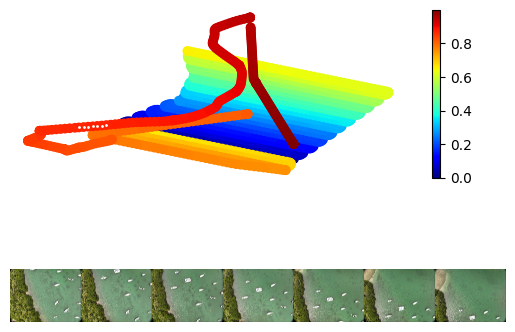

In [2]:
LATLON = gps.to_arc_seconds(coords)

fig, axs = plt.subplots(2)

c = axs[0].scatter(
    LATLON[:, 0],
    LATLON[:, 1],
    c=np.arange(LATLON.shape[0]) / LATLON.shape[0],
    # s=2
    cmap='jet'
)
fig.colorbar(c)

axs[0].scatter(
    LATLON[mask][:, 0],
    LATLON[mask][:, 1],
    s=1,
    c='white'
)

axs[0].axis('off') # The axis is sometimes anisotropically scaled, which is confusing, so I turned off labels

imgs = [
    np.asarray(Image.open(im)) for im in targets
]
axs[1].imshow(np.hstack(imgs))
axs[1].axis('off')

In [3]:
# Find potential floats

import features

float_results = [features.find_floats(im, logs=True) for im in tqdm(imgs)]

  0%|                                                                                                                                                                                           | 0/7 [00:00<?, ?it/s]2026-04-07 16:10:57.187 | DEBUG    | features:find_floats:110 - Finding Gray Mask
2026-04-07 16:10:57.650 | DEBUG    | features:find_floats:113 - Finding Boat Mask
2026-04-07 16:10:57.681 | DEBUG    | features:find_floats:116 - Finding Edge Mask
2026-04-07 16:10:57.717 | DEBUG    | features:find_floats:122 - Finding Line Mask
2026-04-07 16:10:57.726 | DEBUG    | features:line_mask:64 - Found 19 lines

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:09<00:00,  2.03it/s]
2026-04-07 16:11:07.156 | DEBUG    | features:find_floats:126 - Finding Circles
 14%|█████████████████████████▌                                                       

In [9]:
import registration
# Correct for rotation
circles = [i['circles'][0] for i in float_results]
coordinate_frames = [registration.get_image_transform(gps.get_gimbal_yaw(t), imgs[0].shape) for t in targets]
# circles = [registration.image_to_world(c[:, :2], *coord) for c, coord in zip(circles, coordinate_frames)]

In [10]:
# Match Floats
safe_transforms = registration.get_good_transforms(targets, circles, min_correspondances=3, desc_size=100)

# Get a conversion from GPS coordinates to image coordinates
target_coords = np.array([gps.get_coords(str(t)) for t in tqdm(targets)])

M = registration.map_coords_to_image(targets, safe_transforms, gps.to_arc_seconds(target_coords))

Creating descriptors: 0it [00:00, ?it/s]2026-04-07 16:13:22.335 | DEBUG    | registration:create_descriptors:13 - Keeping 88.89% of descriptors (16)
Creating descriptors: 1it [00:00,  5.48it/s]2026-04-07 16:13:22.487 | DEBUG    | registration:create_descriptors:13 - Keeping 100.00% of descriptors (15)
Creating descriptors: 2it [00:00,  6.11it/s]2026-04-07 16:13:22.633 | DEBUG    | registration:create_descriptors:13 - Keeping 100.00% of descriptors (14)
Creating descriptors: 3it [00:00,  6.46it/s]2026-04-07 16:13:22.777 | DEBUG    | registration:create_descriptors:13 - Keeping 92.86% of descriptors (13)
Creating descriptors: 4it [00:00,  6.69it/s]2026-04-07 16:13:22.918 | DEBUG    | registration:create_descriptors:13 - Keeping 83.33% of descriptors (10)
Creating descriptors: 5it [00:00,  6.93it/s]2026-04-07 16:13:23.051 | DEBUG    | registration:create_descriptors:13 - Keeping 79.10% of descriptors (53)
Creating descriptors: 6it [00:00,  5.96it/s]2026-04-07 16:13:23.266 | DEBUG    | reg

Failed to find M for 4, 4


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.64it/s]
2026-04-07 16:13:31.500 | DEBUG    | registration:map_coords_to_image:279 - Saved target transforms


In [15]:
coordinate_frame = registration.get_image_transform(gps.get_gimbal_yaw(target), imgs[0].shape)

In [ ]:
def ransac_transform(A, B):
    assert(A.shape[0] >= 2)
    def solve(v1, v2, z1, z2):
        # AM = B
        # M = A^-1 B
        
        a = np.vstack([
            v1, v2
        ])

        b = np.vstack([
            z1, z2
        ])
        a_inv = np.linalg.inv(a)
        return a_inv @ b

    best_M = None
    best_score = np.inf
    for i in range(A.shape[0]):
        for j in range(A.shape[0]):
            if i == j:
                continue
        try:
            M = solve(
                A[i],
                A[j],
                B[i],
                B[j]
            )
        except:
            print(f"Failed to find M for {i}, {j}")
        score = np.linalg.norm(A @ M - B, axis=-1)
        score = np.median(score)
        if score < best_score:
            best_M = M
            best_score = score
    return best_M,  best_score
    

In [ ]:
M, s = ransac_transform(offsets, translations)
s

In [ ]:
for idx, q in enumerate(tqdm(safe_transforms)):
    q = q[0]
    t = offsets[idx] @ M
    im1 = np.mean(np.asarray(Image.open(targets[q[0]])), axis=-1)
    warped = cv2.warpAffine(im1, np.array([[1, 0, t[0]], [0, 1, t[1]]]), im1.shape[:2][::-1])
    im2 = np.mean(np.asarray(Image.open(targets[q[1]])), axis=-1)
    # result = (
    #     (warped + im2) / 2
    # )
    result = np.dstack([
        warped,
        im2,
        np.zeros_like(im1)
    ]).astype(np.uint8)
    cv2.imwrite(f"rewarping_{idx}.jpg", result.astype(np.uint8))

In [ ]:
ID = 0
q = safe_transforms[ID][0]
t = offsets[ID] @ M
im1 = np.asarray(Image.open(targets[q[0]]))
warped = cv2.warpAffine(im1, np.array([[1, 0, t[0]], [0, 1, t[1]]]), im1.shape[:2][::-1]).astype(np.float32)
im2 = np.asarray(Image.open(targets[q[1]])).astype(np.float32)
# fig, axs = plt.subplots(1, 2)
# axs[0].imshow(np.asarray(Image.open(targets[q[0]])))
# axs[1].imshow(np.asarray(Image.open(targets[q[1]])))
# for ax in axs:
#     ax.axis('off')
plt.imshow(
    (warped + im2) / (255 * 2)
)
# plt.imshow(warped / 255)

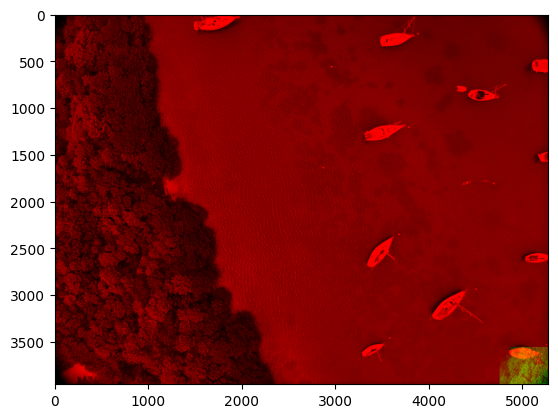

In [56]:
q = 0
im1 = np.mean(np.asarray(Image.open(targets[0])), axis=-1) / 255
t = (np.array(im1.shape[::-1]) * 0.9) @ np.linalg.inv(M) @ M
warped = cv2.warpAffine(im1, np.array([[1, 0, t[0]], [0, 1, t[1]]]), im1.shape[:2][::-1]).astype(np.float32)

plt.imshow(
    np.dstack([im1, warped, np.zeros_like(im1)])
)
# plt.imshow(warped / 255)

In [ ]:
t

In [ ]:
translations

In [ ]:
# homog = np.vstack([M, [[0, 0]]]).T # Now can left multiply instead of right multiply
# homog

In [ ]:
M.shape

In [ ]:
offsets @ M - translations

In [ ]:
np.vstack([[1, 2], [3, 4]])

In [ ]:
# offsets
# translations

In [ ]:
coords1

In [ ]:
descriptors, matches = floats.match_images(targets, res, matching_query=queries, DESC_SIZE=100)

In [ ]:
pitches = [gps.get_gimbal_pitch(t) for t in targets]

In [ ]:
pitches

In [ ]:
translations = []

for Q in tqdm(range(len(queries))):
    q = queries[Q]
    P1 = targets[q[0]]
    P2 = targets[q[1]]
    M = matches[Q][0]
    mask = matches[Q][1]
    
    C1 = descriptors[q[0]][0][mask.astype(bool)]
    C2 = descriptors[q[1]][0]
    
    c = floats.draw_matches(P1, P2, M, C1, C2)
    cv2.imwrite(f"match_{Q}.jpg", c[..., ::-1])
    t, b, s, count, mask = ransac_d(C1, C2[M[:, 0].astype(int)], error=30)
    # t, b, s, count, mask = ransac_e(C1, C2[M[:, 0].astype(int)])
    np.sum(mask)
    if count > 2:
        translations.append(t)
    translations.append(t)

    c = floats.draw_matches(P1, P2, M[mask], C1[mask], C2)
    cv2.imwrite(f"ransac_match_{Q}.jpg", c[..., ::-1])

In [ ]:

def ransac_d(c1, c2, error=0.01):
    t = c2 - c1
    best = 0
    best_count = -np.inf
    best_score = np.inf
    for idx, i in enumerate(t):
        score = np.linalg.norm(t - i, axis=-1)
        # score = (t @ i) / (i @ i)
        mask = score < error
        s = np.sum(mask)
        score = np.mean(score[mask])
        print(s, score)
        if s > best_count or s == best_count and score < best_score:
            best = idx
            best_count = s
            best_score = score

    score = np.linalg.norm(t - t[best], axis=-1)
    mask = score < error
    return t[best], best, best_score, best_count, mask

In [ ]:

def ransac_e(c1, c2):
    aff, inl = cv2.estimateAffinePartial2D(c1, c2)
    # t = c2 - c1
    # best = 0
    # best_count = -np.inf
    # best_score = np.inf
    # for idx, i in enumerate(t):
    #     score = np.linalg.norm(t - i, axis=-1)
    #     # score = (t @ i) / (i @ i)
    #     mask = score < error
    #     s = np.sum(mask)
    #     score = np.mean(score[mask])
    #     print(s, score)
    #     if s > best_count or s == best_count and score < best_score:
    #         best = idx
    #         best_count = s
    #         best_score = score

    # score = np.linalg.norm(t - t[best], axis=-1)
    # mask = score < error
    # return t[best], best, best_score, best_count, mask
    return aff, 0, 0, np.sum(inl), inl[:, 0].astype(bool)

In [ ]:
Q = -1
q = queries[Q]
P1 = targets[q[0]]
P2 = targets[q[1]]
M = matches[Q][0]
mask = matches[Q][1]

C1 = descriptors[q[0]][0][mask.astype(bool)]
C2 = descriptors[q[1]][0]

c1 = floats.draw_matches(P1, P2, M, C1, C2)
# cv2.imwrite(f"match_{Q}.jpg", c[..., ::-1])
t, b, s, count, mask = ransac_e(C1, C2[M[:, 0].astype(int)])
np.sum(mask)
if count > 2:
    translations.append(t)
translations.append(t)

c2 = floats.draw_matches(P1, P2, M[mask], C1[mask], C2)
# cv2.imwrite(f"ransac_match_{Q}.jpg", c[..., ::-1])

In [ ]:
plt.imshow(c1)

In [ ]:
plt.imshow(c2)
plt.axis('off')

In [ ]:
np.linalg.norm(t, axis=-1)

In [17]:
import rasterio
from rasterio.transform import Affine

NameError: name 'image' is not defined

In [93]:
from pathlib import Path

In [101]:
Path(target).stem

'DJI_20260401153132_0084_V'

In [121]:
def save_image(target):
    tiff = np.asarray(Image.open(target))
    
    height, width = tiff.shape[:2]
    
    inv_M = np.linalg.inv(M)
    C = gps.to_arc_seconds(gps.get_coords(target))
    ctr = np.array([width, height]) / 2
    TL = np.array([0, 0]) @ np.linalg.inv(M) + C
    BL = np.array([0, height]) @ np.linalg.inv(M) + C
    TR = np.array([width, height]) @ np.linalg.inv(M) + C
    tiff = tiff[::16, ::16]
    height, width = tiff.shape[:2]
    
    # Example: your image (H x W or H x W x bands)
    
    
    # ---- INPUTS YOU SAID YOU HAVE ----
    # Coordinates of corners (example: top-left, top-right, bottom-left)
    # Replace with your actual values
    (x_tl, y_tl) = TL[::-1] / 3600
    (x_tr, y_tr) = BL[::-1] / 3600
    (x_bl, y_bl) = TR[::-1] / 3600
    
    # ---- COMPUTE AFFINE TRANSFORM ----
    # Pixel size vectors
    dx_col = (x_tr - x_tl) / width
    dy_col = (y_tr - y_tl) / width
    
    dx_row = (x_bl - x_tl) / height
    dy_row = (y_bl - y_tl) / height
    
    transform = Affine(
        dx_col, dx_row, x_tl,
        dy_col, dy_row, y_tl
    )
    
    def prep_raster_for_rasterio(img):
        # img: (1, H, W, C) → (C, H, W)
        # img = img.squeeze(0)          # remove batch dim
        img = img.transpose(2, 0, 1)  # channels last → first
        return img
    
    # ---- WRITE GEOTIFF ----
    with rasterio.open(
        f"output_{Path(target).stem}.tif",
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=3,  # number of bands
        dtype=tiff.dtype,
        crs="EPSG:4326",  # change if needed
        transform=transform,
    ) as dst:
        dst.write(prep_raster_for_rasterio(tiff))
    
    print("GeoTIFF written successfully.")

In [126]:
IMGS = np.random.randint(0, len(images), 10)
for t in tqdm(IMGS):
    save_image(str(images[t]))


 20%|███████████████████████████████████▌                                                                                                                                              | 2/10 [00:00<00:01,  7.75it/s]

GeoTIFF written successfully.
GeoTIFF written successfully.


 50%|█████████████████████████████████████████████████████████████████████████████████████████                                                                                         | 5/10 [00:00<00:00,  9.53it/s]

GeoTIFF written successfully.
GeoTIFF written successfully.
GeoTIFF written successfully.


 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                   | 8/10 [00:00<00:00, 10.02it/s]

GeoTIFF written successfully.
GeoTIFF written successfully.
GeoTIFF written successfully.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  9.55it/s]

GeoTIFF written successfully.
GeoTIFF written successfully.


In [61]:
(np.array([width, height]) / 2) @ np.linalg.inv(M)

array([ 0.39539678, -2.01961639])

In [86]:
TL / 3600, BL / 3600, TR / 3600

(array([ 25.72461767, -80.15886822]),
 array([ 25.72558953, -80.15864409]),
 array([ 25.72483733, -80.15999023]))

GeoTIFF written successfully.


In [73]:
tiff.squeeze

<function ndarray.squeeze(axis=None)>